In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [51]:
df = pd.read_csv('https://github.com/AkarshVyas/Machine-Learning-Part-1/raw/refs/heads/main/insurance.csv')

In [52]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#EDA

In [53]:
df.shape

(1338, 7)

In [54]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [56]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [57]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [58]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

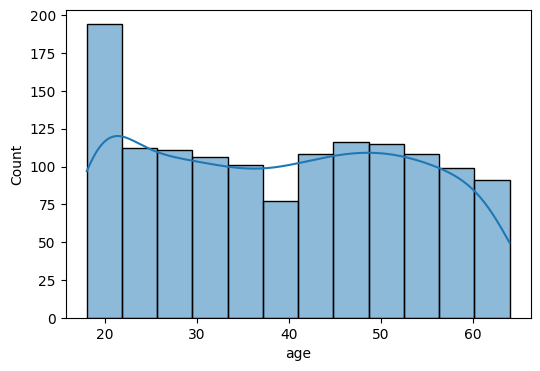

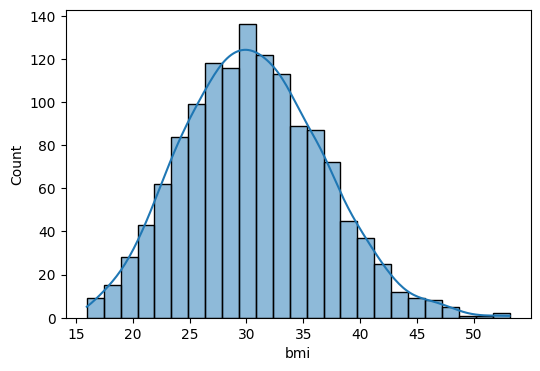

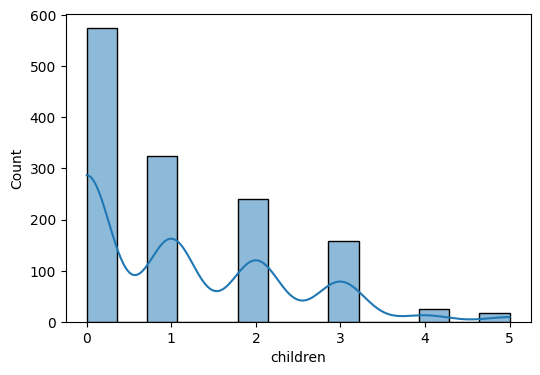

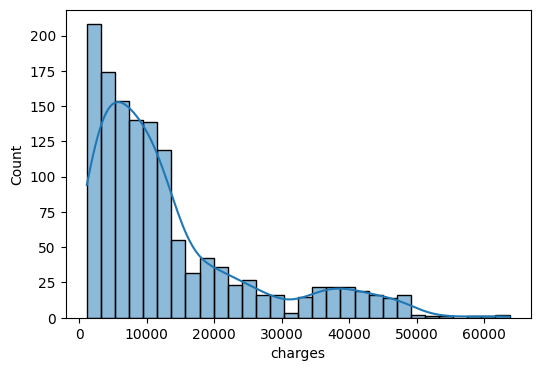

In [59]:
#visualizing the data (distribution of numeric varialbes):
numeric_cols = ['age', 'bmi', 'children', 'charges']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)

<Axes: xlabel='children', ylabel='count'>

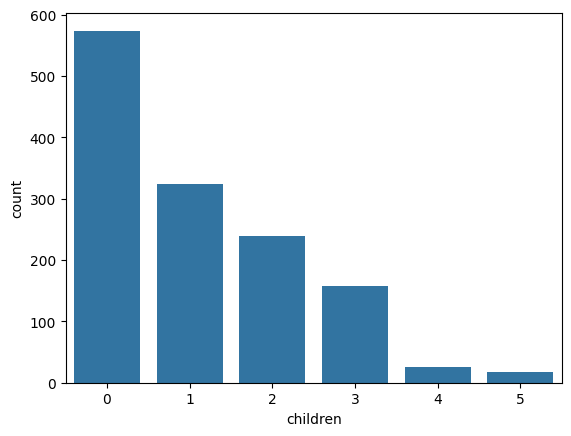

In [60]:
# count plots for categorical vars & (children to make better sense)
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

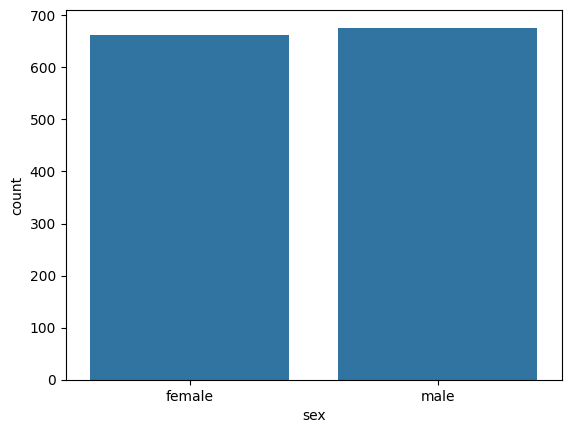

In [61]:
sns.countplot(x = df['sex'])
# can also do a histplot but would look unclean:  sns.histplot(df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

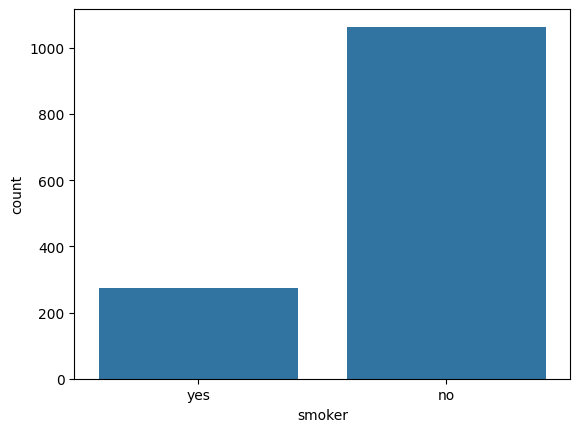

In [62]:
sns.countplot(x = df['smoker'])

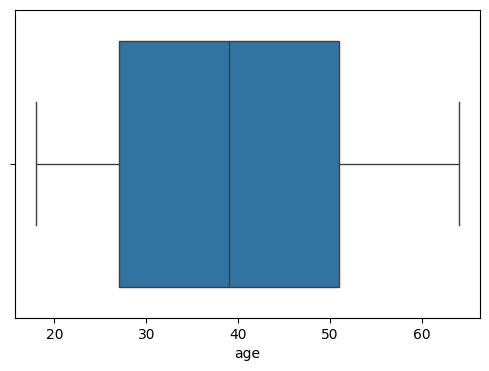

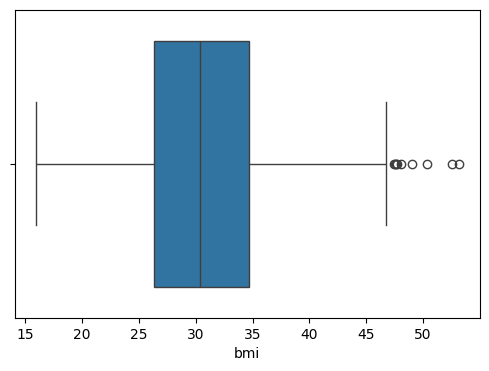

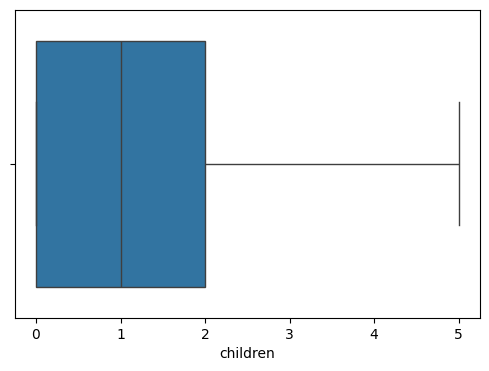

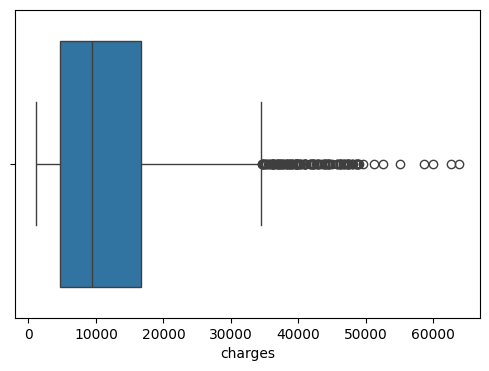

In [63]:
# looking for outliers (using boxplot)
for col in numeric_cols:
    plt.figure(figsize= (6,4))
    sns.boxplot(x=df[col])

<Axes: >

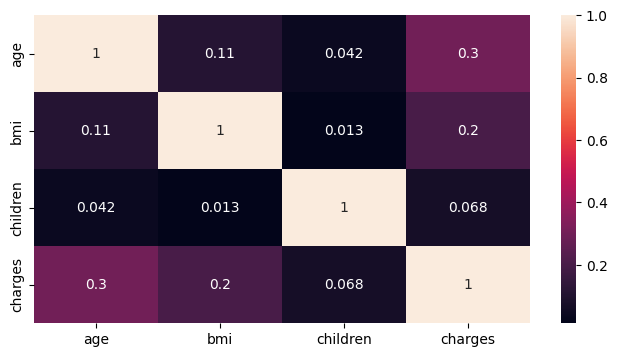

In [64]:
#looking for the correlation between the numeric vars:
plt.figure(figsize= (8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

#Data Cleaning and Processing

In [65]:
#since this is kaggle dataset (not much need of cleaning)
df_cleaned = df.copy()

In [66]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [67]:
df_cleaned.shape

(1338, 7)

In [68]:
df_cleaned.drop_duplicates(inplace=True)

In [69]:
df_cleaned.shape

(1337, 7)

In [70]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [71]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [72]:
df_cleaned['sex'].value_counts() ## we must encode this into 0 and 1 for training model (a part of data cleaning)

sex
male      675
female    662
Name: count, dtype: int64

In [73]:
#utilizng label encoding for two types of values in sex:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0, 'female':1})

In [74]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [75]:
#encoding check for smoker
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [76]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no' : 0, 'yes' : 1})

In [77]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [78]:
#renaming sex to isfemale and {smoker} to isSmoker
# learning: note: {'': 234, '':''} -> this is called dictionary

df_cleaned.rename(columns={
     'sex' : 'is_female',
     'smoker' : 'is_smoker'
},inplace=True)

In [79]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [80]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [81]:
# recall dummies:
df_cleaned = pd.get_dummies(df_cleaned, columns= ['region'], drop_first=True)

In [82]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [83]:
df_cleaned = df_cleaned.astype(int) # astype will convert any other (convertible) datatypes into here(int). we already have solved other strings just focusing on boolean now

In [84]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


#Feature Engineering and Extraction

In [85]:
#creating new column/variable using the exisiting variables: for now using the bmi || in later project Dipen you will have to do research on the data again:

df_cleaned['bmi_category'] = pd.cut( #df_cleaned['bmi_category'] is the new engineered feature
    df_cleaned['bmi'], #the exisiting feature
    bins=[0,18.5,24.9,29.9,float('inf')], #categorizing filters (intervals)
    labels=['Underweight','Healthy','Overweight','Obese'] # corresponding labels according to intervals(bins)
)

In [86]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Healthy
4,32,0,28,0,0,3866,1,0,0,Overweight


In [87]:
#encoding the bmi_category using one hot labeling using dummies
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first= True)

In [88]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Healthy,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [89]:
df_cleaned = df_cleaned.astype(int)

In [90]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Healthy,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [91]:
df_cleaned.dtypes # using dtypes for knowing the columns name (i prefer this over .columns)

age                        int64
is_female                  int64
bmi                        int64
children                   int64
is_smoker                  int64
charges                    int64
region_northwest           int64
region_southeast           int64
region_southwest           int64
bmi_category_Healthy       int64
bmi_category_Overweight    int64
bmi_category_Obese         int64
dtype: object

In [92]:
#scaling the data that i think need them:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler() #scaler object

#entering the scaling required columns (cols) into scaler to scale and updating them as below:
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [93]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Healthy,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [94]:
target_col = 'charges'
correlation = df_cleaned.corr(numeric_only=True)
print(correlation[target_col].sort_values(ascending= False))

charges                    1.000000
is_smoker                  0.787234
age                        0.298309
bmi_category_Obese         0.200348
bmi                        0.196236
region_southeast           0.073577
children                   0.067390
region_northwest          -0.038695
region_southwest          -0.043637
is_female                 -0.058046
bmi_category_Healthy      -0.104042
bmi_category_Overweight   -0.120601
Name: charges, dtype: float64


In [99]:
cat_features = ['is_female', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Healthy', 'bmi_category_Overweight', 'bmi_category_Obese']

In [95]:
df_cleaned["charges_bin"] = pd.qcut(
    df["charges"],
    q=4,
    labels=False
)

In [102]:
#checking for the categorical features: (using chi-squared test: null -> the feature and target are independent)
from scipy.stats import chi2_contingency
alpha = 0.05
results = []  

for col in cat_features:
    contingency_table = pd.crosstab(df_cleaned[col],df_cleaned['charges_bin'])
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)
    decision = 'Reject Null (Keep feature)' if (p_val < alpha) else 'Cannot Reject Null (Omit feature)'

    results.append({
        "feature": col,
        "chi2_statistic": chi2,
        "p_value": p_val,
        "Decision": decision
    })

chi2_results = pd.DataFrame(results)
chi2_results.sort_values("p_value")

chi2_results

,feature,chi2_statistic,p_value,Decision
0,is_female,9.467253,2.368229e-02,Reject Null (Keep feature)
1,is_smoker,853.288819,1.198625e-184,Reject Null (Keep feature)
2,region_northwest,1.194988,7.542066e-01,Cannot Reject Null (Omit feature)
3,region_southeast,15.252300,1.613255e-03,Reject Null (Keep feature)
4,region_southwest,5.517988,1.375667e-01,Cannot Reject Null (Omit feature)
5,bmi_category_Healthy,3.661126,3.004580e-01,Cannot Reject Null (Omit feature)
6,bmi_category_Overweight,4.630431,2.009470e-01,Cannot Reject Null (Omit feature)
7,bmi_category_Obese,8.689643,3.371493e-02,Reject Null (Keep feature)


In [111]:
df_final = df_cleaned.drop(columns = ['region_northwest','region_southwest','bmi_category_Healthy','bmi_category_Overweight','charges_bin'])
df_final

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


(1337, 8)